<a href="https://colab.research.google.com/github/emirpeker/Veri-Analizi-Okulu/blob/main/Veri_Analiz_Okulu%2C_Yapay_Zeka__Makina_%C3%96%C4%9Frenmesi%2C_Ders_5_Uygulama_Script_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Çok Sınıflı Sınıflandırma - Yapay Sinir Ağları ile**

Bu uygulama; Palmer Penguenleri'nin üç farklı türünü, fiziksel ölçümlerine ve yaşam alanlarına dayanarak sınıflandıran, Yapay Sinir Ağı (YSA) kullanan bir denetimli makine öğrenmesi iş akışını göstermektedir."Gerçek dünya" verilerindeki eksik değerlerin işlenmesinden kategorik kodlamaya, özellik ölçeklendirmeden Keras ile model eğitimine kadar tüm veri yaşam döngüsünü içermektedir. Model, Softmax çıktı katmanını kullanarak olasılık tabanlı tahminler sunar ve sinir ağlarının çok sınıflı karar verme süreçlerini nasıl yönettiğini göstermektedir.

Modüllerin yüklenmesi

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [ ]:
df = sns.load_dataset('penguins')

print("Veri Boyutu:", df.shape)
df.head()

Veri Boyutu: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


Veri Hazırlama

In [ ]:
# Eksik verili satırların silinmesi
df = df.dropna()
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [ ]:
print("Veri Boyutu:", df.shape)

Veri Boyutu: (333, 7)


In [ ]:

# Özelliklerin ve Hedeflerin Ayrılması
X = df.drop('species', axis=1)
y = df['species']

# Kategorik Verileri Kodla (Island ve Sex)
# Dizeleri sayılara dönüştürmek için pd.get_dummies kullanıyoruz (One-Hot Kodlama)
X = pd.get_dummies(X, columns=['island', 'sex'], drop_first=True)

#Hedef Değişkeni (Türleri) Kodla
#Sinir ağları, hedef değişkenin sayısal veya one-hot kodlanmış olmasını gerektirir
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Orijinal Sınıflar: {le.classes_}")
print(f"Kodlanmış Sınıflar: {np.unique(y_encoded)}")

Orijinal Sınıflar: ['Adelie' 'Chinstrap' 'Gentoo']
Kodlanmış Sınıflar: [0 1 2]


In [ ]:
X

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_Male
0,39.1,18.7,181.0,3750.0,False,True,True
1,39.5,17.4,186.0,3800.0,False,True,False
2,40.3,18.0,195.0,3250.0,False,True,False
4,36.7,19.3,193.0,3450.0,False,True,False
5,39.3,20.6,190.0,3650.0,False,True,True
...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,False,False,False
340,46.8,14.3,215.0,4850.0,False,False,False
341,50.4,15.7,222.0,5750.0,False,False,True
342,45.2,14.8,212.0,5200.0,False,False,False


Veriyi Bölme ve Ölçekleme

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Veriyi Bölme - Eğitim/Training (60%) and Testing (40%)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.4, random_state=42)

# Veriyi Ölçekleme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
X_train.size

1393

In [ ]:
X_test.size

938

Yapay Sinir Ağını Kurmak

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    # Giriş Katmanı ve İlk Gizli Katman
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    # İkinci Gizli Katman
    Dense(8, activation='relu'),
    # Çıkış Katmanı : 3 adet her bir tür için
    Dense(3, activation='softmax')
])

# çok sınıflı sınıflandırma için gerekli olan parametreler ile model kurulur
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_15 (Dense)                │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 291 (1.14 KB)

 Trainable params: 291 (1.14 KB)

 Non-trainable params: 0 (0.00 B)

Eğitim ve Değerlenirme

In [ ]:
# Modelin Eğitilmesi
history = model.fit(X_train, y_train, epochs=50, validation_split=0.3, verbose=1)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.6860 - loss: 0.7887 - val_accuracy: 0.8833 - val_loss: 0.6751
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7752 - loss: 0.7267 - val_accuracy: 0.8833 - val_loss: 0.6447
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7366 - loss: 0.7257 - val_accuracy: 0.8833 - val_loss: 0.6159
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7833 - loss: 0.6720 - val_accuracy: 0.9000 - val_loss: 0.5885
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8268 - loss: 0.6511 - val_accuracy: 0.9500 - val_loss: 0.5624
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8218 - loss: 0.6288 - val_accuracy: 0.9667 - val_loss: 0.5365
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9244 - loss: 0.6106 - val_accuracy: 0.9667 - val_loss: 0.5117
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.9255 - loss: 0.5639 - val_accuracy: 0.9667 - val_loss: 0.4879


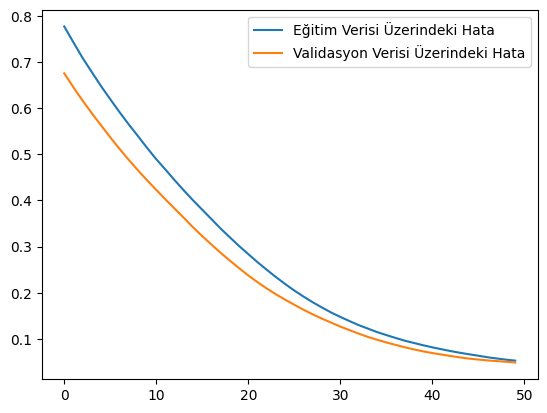

In [ ]:
plt.plot(history.history['loss'], label='Eğitim Verisi Üzerindeki Hata')
plt.plot(history.history['val_loss'], label='Validasyon Verisi Üzerindeki Hata')
plt.legend()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9945 - loss: 0.0425 

Test Doğruluğu: 99.25%


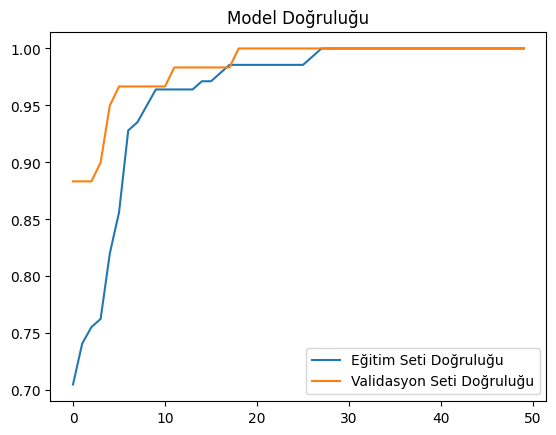

In [ ]:
# Test Verisi Üzerinde değerlendirme
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\nTest Doğruluğu: {test_acc*100:.2f}%")

# Visualization of training progress
plt.plot(history.history['accuracy'], label='Eğitim Seti Doğruluğu')
plt.plot(history.history['val_accuracy'], label='Validasyon Seti Doğruluğu')
plt.title('Model Doğruluğu')
plt.legend()
plt.show()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
Ortalama Doğruluk: 0.9925
F1-Score: 0.9925

Detaylı Kümeleme Raporu:
              precision    recall  f1-score   support

      Adelie       0.98      1.00      0.99        65
   Chinstrap       1.00      0.96      0.98        27
      Gentoo       1.00      1.00      1.00        42

    accuracy                           0.99       134
   macro avg       0.99      0.99      0.99       134
weighted avg       0.99      0.99      0.99       134



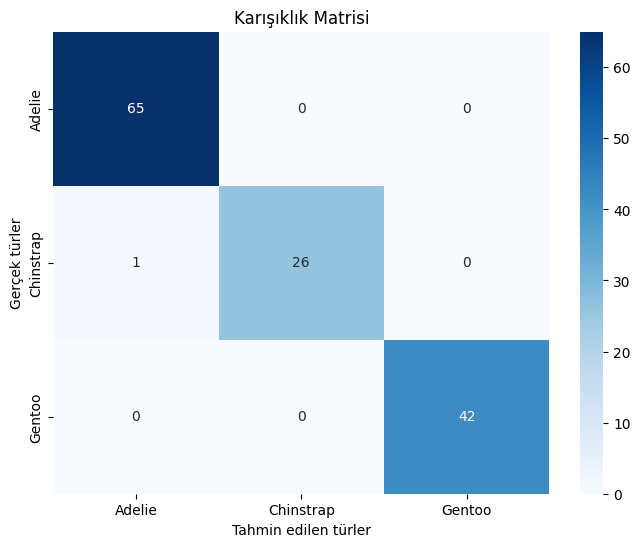

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
import seaborn as sns

# 1. Test Veri setini modele tahminlet
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# 2. metriklerin hesaplanması
accuracy = accuracy_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred,average='weighted')

print(f"Ortalama Doğruluk: {accuracy:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nDetaylı Kümeleme Raporu:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# 3. Karmaşıklık Matrisi
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Tahmin edilen türler')
plt.ylabel('Gerçek türler')
plt.title('Karışıklık Matrisi')
plt.show()

Model hazır olduktan sonra nasıl bır veri noktasını tahminletiriz ?

In [ ]:
# 1. Test verisinden bir satır seçilir
single_sample = X_test[0:1]
single_sample

array([[-0.91642451, -0.20021488, -1.69342818, -1.19778865,  1.2858201 ,
        -0.37032804, -1.03581691]])

In [ ]:
# 2. Olasılık dağılımı tahmin ettirilir
prediction_probs = model.predict(single_sample)
prediction_probs

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


array([[0.8718129 , 0.12325822, 0.00492887]], dtype=float32)

In [ ]:
# 3. Olasılığı en yüksek indeksli tür bulunur
predicted_class_index = np.argmax(prediction_probs)
predicted_class_index

np.int64(0)

In [ ]:
# 4. bulunan indek ters transformasyonla gerçek tür adı tahminlenir
predicted_species = le.inverse_transform([predicted_class_index])
predicted_species

array(['Adelie'], dtype=object)

In [ ]:
print(f"Her sınıf için olasılıklar: {prediction_probs}")
print(f"Tahmin edilen tür: {predicted_species[0]}")
print(f"Gerçek tür: {le.inverse_transform([y_test[0]])[0]}")

Her sınıf için olasılıklar: [[0.8718129  0.12325822 0.00492887]]
Tahmin edilen tür: Adelie
Gerçek tür: Adelie
